In [2]:
import numpy as np
import matplotlib.pylab as plt

In [3]:
def parserSizeSeries(file):
    line = file.readline()
    vertexSet = {}
    dense = {}
    sparse = {}
    while line != "":
        chunks = line.split(",")
        size = (int(chunks[0]))
        if (size in vertexSet.keys()):
            vertexSet[size].append(float(chunks[1]))
            dense[size].append(float(chunks[2]))
            sparse[size].append(float(chunks[3]))
        else:
            vertexSet[size] =[float(chunks[1])]
            dense[size] = [float(chunks[2])]
            sparse[size] =[float(chunks[3])]
        line = file.readline()
    return vertexSet, dense, sparse

def parserFillingSeries(file):
    line = file.readline()
    vertexSet = {}
    dense = {}
    sparse = {}
    while line != "":
        chunks = line.split(",")
        filling = (float(chunks[0]))
        if (filling in vertexSet.keys()):
            vertexSet[filling].append(float(chunks[1]))
            dense[filling].append(float(chunks[2]))
            sparse[filling].append(float(chunks[3]))
        else:
            vertexSet[filling] =[float(chunks[1])]
            dense[filling] = [float(chunks[2])]
            sparse[filling] =[float(chunks[3])]
        line = file.readline()
    return vertexSet, dense, sparse

def parser(filename):
    file = open(filename)
    line = file.readline()
    if (line == "SetSize, VertexSet Time [s], Dense Time [s], Sparse Time [s]\n"):
        return parserSizeSeries(file)
    elif (line == "Fillage, VertexSet Time [s], Dense Time [s], Sparse Time [s]\n"):
        return parserFillingSeries(file)
    else:
        print("Error: Wrong format for parser")
        return


def getMeanAndError(dict):
    sizes = []
    means = []
    errors = []
    for size in dict.keys():
        sizes.append(size)
        array = np.array(dict[size])
        means.append(np.mean(array))
        if array.size > 0:
            errors.append(np.std(array))
        else:
            errors.append(0)
    return sizes, means, errors

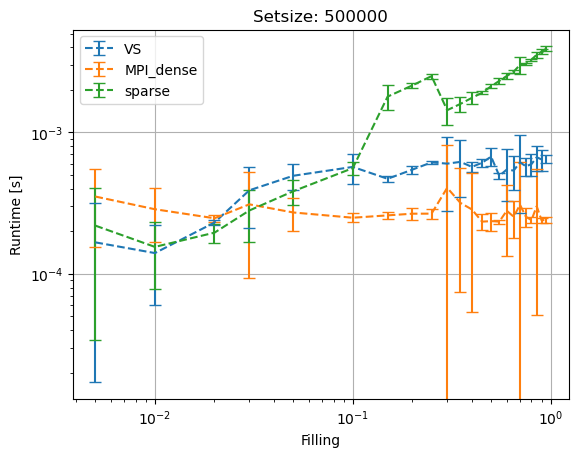

In [6]:
# filling series plot
setsize = "500000"
NNodes = 32
perNode = 17
func = "approx_Halfing"

filepath = "data/performanceData/" + func + "_" + str(NNodes) + "x" + str(perNode) +  "_fillingSeries_" + setsize + ".txt"

vertexSet, dense, sparse = parser(filepath)

fig = plt.figure
ax = plt.axes()

fillings, vals, errors = getMeanAndError(vertexSet)
ax.errorbar(fillings, vals, yerr=errors, ls="--", capsize=4, label="VS")

fillings, vals, errors = getMeanAndError(dense)
ax.errorbar(fillings, vals, yerr=errors, ls="--", capsize=4, label="MPI_dense")

fillings, vals, errors = getMeanAndError(sparse)
ax.errorbar(fillings, vals, yerr=errors, ls="--", capsize=4, label="sparse")

ax.set_yscale("log")
ax.set_xscale("log")

ax.grid()
ax.set_xlabel("Filling")
ax.set_ylabel("Runtime [s]")
ax.legend()
plt.title("Setsize: " + setsize)


plt.savefig("./data/figs/fillingSeries_" + setsize + ".png")

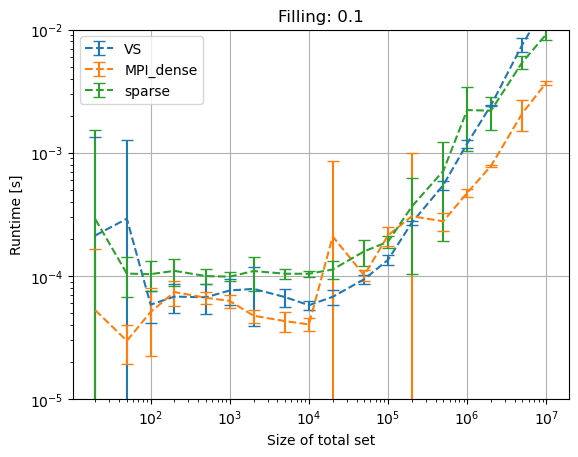

In [7]:
filling = "0.100000"

filepath = "data/performanceData/" + func + "_" + str(NNodes) + "x" + str(perNode) +  "_sizeSeries_" + filling + ".txt"


vertexSet, dense, sparse = parser(filepath)

fig = plt.figure
ax = plt.axes()

sizes, vals, errors = getMeanAndError(vertexSet)
ax.errorbar(sizes, vals, ls="--", yerr=errors, capsize=4, label="VS")

sizes, vals, errors = getMeanAndError(dense)
ax.errorbar(sizes, vals, ls="--", yerr=errors, capsize=4, label="MPI_dense")

sizes, vals, errors = getMeanAndError(sparse)
ax.errorbar(sizes, vals, ls="--", yerr=errors, capsize=4, label="sparse")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim((1e-5, 1e-2))

ax.grid()
ax.set_xlabel("Size of total set")
ax.set_ylabel("Runtime [s]")
ax.legend()
plt.title("Filling: 0.1")

plt.savefig("./data/figs/sizeSeries.png")